# Ridge Regression

## What it does
**Ridge regression** adds an L2 penalty to OLS, shrinking coefficients toward zero:
$$\hat{\beta}_{\text{ridge}} = \arg\min_\beta \|y - X\beta\|^2 + \alpha \|\beta\|^2$$

Unlike Lasso, Ridge retains all features but shrinks them smoothly — it never sets coefficients
exactly to zero. This makes it preferable when many features contribute weakly.

## When to use it
- Many correlated predictors (Ridge handles multicollinearity better than OLS)
- You want a dense model (all features contribute)
- Strong baseline before trying non-linear models

## Data format
Panel CSV/Parquet with `DATE_COL`, `ID_COL`, `TARGET_COL`; all other numeric columns are features.

## Configuration

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,
    # --- Ridge alpha grid ---
    'RIDGE_ALPHAS':       [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         '../../results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  RIDGE_ALPHAS: [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, date_col=CONFIG['DATE_COL'],
    train_years=CONFIG['TRAIN_YEARS'], val_years=CONFIG['VAL_YEARS'],
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

In [4]:
X, y, feature_cols = prepare_panel_data(
    df, target_col=CONFIG['TARGET_COL'],
    exclude_cols=[CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value=CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)
    print('Features standardized (fit on training data only).')

y_train_mean = float(y_train.mean())
print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

Features standardized (fit on training data only).
Features      : 209
Train obs     : 884
Training mean : 0.007120


## Step 3 — Ridge Grid Search

Best alpha selected by **validation OOS R²** — test set never touched.

In [5]:
ridge_results = []

for alpha in CONFIG['RIDGE_ALPHAS']:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    oos_r2   = compute_oos_r2(y_val.values, val_pred, y_train_mean)
    ridge_results.append({'alpha': alpha, 'oos_r2_val': oos_r2, 'model': model})
    print(f'  alpha={alpha:.4f}  Val OOS R²={oos_r2*100:+.4f}%')

best_ridge = max(ridge_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest alpha: {best_ridge['alpha']}  (Val OOS R² = {best_ridge['oos_r2_val']*100:+.4f}%)")

  alpha=0.0100  Val OOS R²=-403.2363%


  alpha=0.1000  Val OOS R²=-402.2708%


  alpha=1.0000  Val OOS R²=-393.1886%
  alpha=10.0000  Val OOS R²=-332.5845%
  alpha=100.0000  Val OOS R²=-131.8140%
  alpha=1000.0000  Val OOS R²=+8.2505%

Best alpha: 1000.0  (Val OOS R² = +8.2505%)


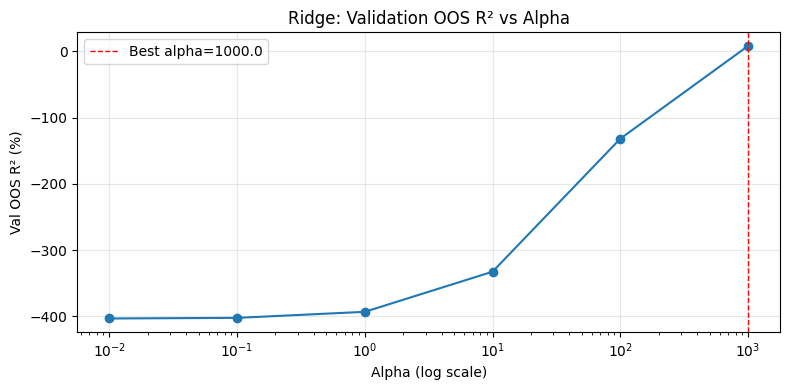

In [6]:
alphas_plot  = [r['alpha'] for r in ridge_results]
oos_r2_plot  = [r['oos_r2_val'] * 100 for r in ridge_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas_plot, oos_r2_plot, marker='o', linewidth=1.5)
ax.axvline(x=best_ridge['alpha'], color='red', linestyle='--', linewidth=1, label=f"Best alpha={best_ridge['alpha']}")
ax.set(xlabel='Alpha (log scale)', ylabel='Val OOS R² (%)', title='Ridge: Validation OOS R² vs Alpha')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [7]:
best_model = best_ridge['model']

preds = {
    'train': best_model.predict(X_train),
    'val':   best_model.predict(X_val),
    'test':  best_model.predict(X_test),
}

metrics = evaluate_splits(
    y_train, preds['train'], y_val, preds['val'], y_test, preds['test'],
    train_mean=y_train_mean,
)

print('RIDGE — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  Alpha          : {best_ridge['alpha']}")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

RIDGE — BEST MODEL EVALUATION
  Alpha          : 1000.0

  Train R²       : +19.1904%
  Val R²         : +6.6119%
  Test R²        : -397.3133%

  OOS R² Val     : +8.2505%
  OOS R² Test    : -394.5400%


## Step 5 — Top Coefficients

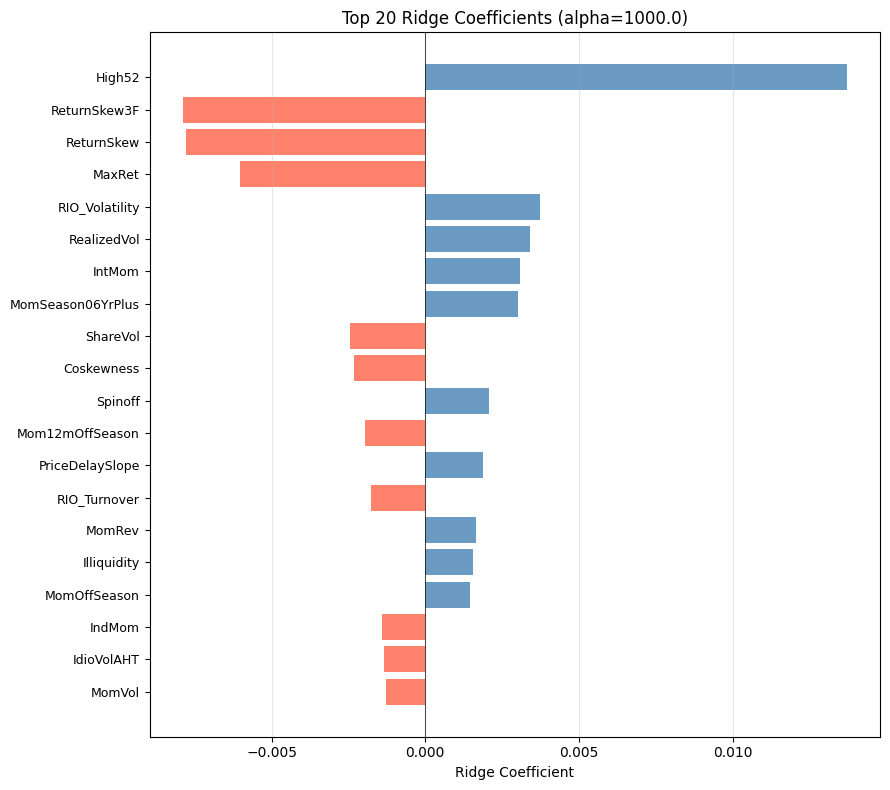


Top 10 features by |coefficient|:
          feature      coef
           High52  0.013715
     ReturnSkew3F -0.007885
       ReturnSkew -0.007797
           MaxRet -0.006024
   RIO_Volatility  0.003746
      RealizedVol  0.003409
           IntMom  0.003084
MomSeason06YrPlus  0.003005
         ShareVol -0.002459
       Coskewness -0.002306


In [8]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef':    best_model.coef_,
}).sort_values('coef', key=abs, ascending=False)

top_n = min(20, len(coef_df))
top_df = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, max(4, top_n * 0.4)))
colors = ['steelblue' if v > 0 else 'tomato' for v in top_df['coef']]
ax.barh(range(top_n), top_df['coef'].values, color=colors, alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_df['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set(xlabel='Ridge Coefficient', title=f'Top {top_n} Ridge Coefficients (alpha={best_ridge["alpha"]})')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f'\nTop 10 features by |coefficient|:')
print(coef_df.head(10).to_string(index=False))

## Step 6 — Portfolio Formation & Sharpe Ratio

RIDGE LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : 6.8920%
  Std monthly    : 6.9986%
  Sharpe (ann.)  : 3.4113


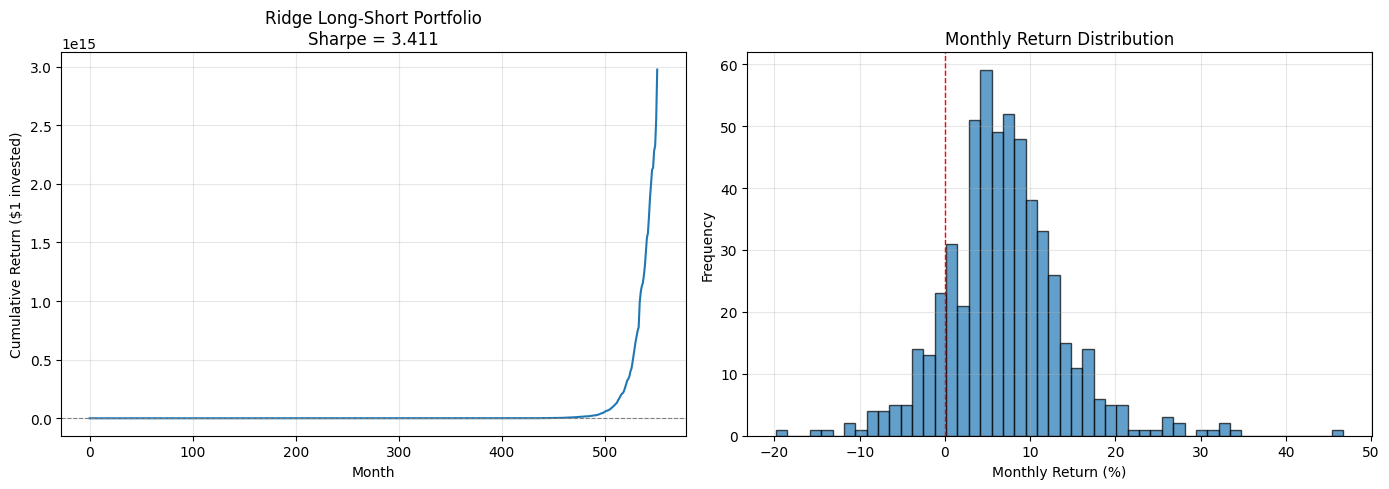

In [9]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base, date_col=CONFIG['DATE_COL'],
    pred_col='predicted_ret', ret_col='actual_ret',
    n_deciles=CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('RIDGE LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'Ridge Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Save Results

In [10]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'Ridge',
        description   = f'Ridge regression (L2 penalty)',
        tuning_params = f"alpha={best_ridge['alpha']}",
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'ridge',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'ridge_summary.csv')
    print(f'Saved: {path}')
    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'ridge_portfolios.csv')
    print(f'Saved: {path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/ridge_summary.csv
Saved: results/ridge_portfolios.csv
